In [70]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import seaborn as sns
import math

In [71]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Using device: cuda
Device name: NVIDIA GeForce RTX 4080 Laptop GPU


In [72]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

In [73]:
train_df = pd.read_csv('data/processed/train_FD001_processed.csv')
test_df = pd.read_csv('data/processed/test_FD001_processed.csv')

In [74]:
np.random.seed(42)
all_engine_ids = train_df['engine'].unique()
np.random.shuffle(all_engine_ids)
split_percentage = 0.8
split_point = int(len(all_engine_ids) * split_percentage)

train_subset_ids = all_engine_ids[:split_point]
validation_ids = all_engine_ids[split_point:]

train_subset_df = train_df[train_df['engine'].isin(train_subset_ids)]
val_subset_df = train_df[train_df['engine'].isin(validation_ids)]

In [75]:
feature_cols = [col for col in train_df.columns if col not in ['engine', 'cycle', 'RUL']]

scaler = StandardScaler()

scaler.fit(train_subset_df[feature_cols])

train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
val_subset_df[feature_cols] = scaler.transform(val_subset_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

/tmp/ipykernel_3986/1359493829.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_subset_df[feature_cols] = scaler.transform(train_subset_df[feature_cols])
/tmp/ipykernel_3986/1359493829.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_subset_df[feature_cols] = scaler.transform(val_subset_df[feature_cols])


In [76]:
LOOKBACK = 30

def create_sliding_windows_for_transformer(df, lookback=30):
    X, y = [], []
    num_features = df.shape[1] - 3

    for engine_id in df["engine"].unique():
        engine_data = df[df["engine"] == engine_id].reset_index(drop=True)
        for i in range(len(engine_data) - lookback + 1):
            window = engine_data.iloc[i:i + lookback]
            X.append(window.drop(columns=["engine", "cycle", "RUL"]).values)
            y.append(window["RUL"].iloc[-1])

    # Convert to NumPy arrays with the correct shape
    X = np.array(X).reshape(-1, lookback, num_features)
    y = np.array(y).reshape(-1, 1) # Reshape y to (samples, 1) for regression
    return X, y

In [77]:
def get_last_window_per_engine_for_transformer(df, lookback=30):
    X_test, y_test = [], []
    num_features = df.shape[1] - 3

    for engine_id in df["engine"].unique():
        engine_data = df[df["engine"] == engine_id].reset_index(drop=True)
        if len(engine_data) >= lookback:
            window = engine_data.iloc[-lookback:]
            X_test.append(window.drop(columns=["engine", "cycle", "RUL"]).values)
            y_test.append(window["RUL"].iloc[-1])

    X_test = np.array(X_test).reshape(-1, lookback, num_features)
    y_test = np.array(y_test).reshape(-1, 1)
    return X_test, y_test

In [78]:
X_train_np, y_train_np = create_sliding_windows_for_transformer(train_subset_df, lookback=LOOKBACK)
X_val_np, y_val_np = create_sliding_windows_for_transformer(val_subset_df, lookback=LOOKBACK)
X_test_np, y_test_np = get_last_window_per_engine_for_transformer(test_df, lookback=LOOKBACK)

In [79]:
X_train = torch.from_numpy(X_train_np).float()
y_train = torch.from_numpy(y_train_np).float()
X_val = torch.from_numpy(X_val_np).float()
y_val = torch.from_numpy(y_val_np).float()
X_test = torch.from_numpy(X_test_np).float()
y_test = torch.from_numpy(y_test_np).float()

In [80]:
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

print("Data shapes and loader info:")
print(f"X_train tensor shape: {X_train.shape}")
print(f"Number of training batches: {len(train_loader)}")

Data shapes and loader info:
X_train tensor shape: torch.Size([14020, 30, 24])
Number of training batches: 220


In [81]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, d_hid, nlayers, dropout=0.5):
        super(TransformerModel, self).__init__()
        self.model_type = 'Transformer'
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead, d_hid, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, nlayers)
        self.encoder = nn.Linear(input_dim, d_model)
        self.d_model = d_model
        self.decoder = nn.Linear(d_model, 1) # Output is a single RUL value

    def forward(self, src):
        src = self.encoder(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        # We use the output of the last time step for prediction
        output = self.decoder(output[:, -1, :])
        return output

In [82]:
input_dim = X_train.shape[2]  # Number of features
d_model = 128
nhead = 8
d_hid = 256
nlayers = 4
dropout = 0.2

In [83]:
model = TransformerModel(input_dim, d_model, nhead, d_hid, nlayers, dropout).to(device)
print(model)

TransformerModel(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (encoder): Linear(in_features=24, out_features=128, bias=True)
  (decoder): Linear(in_features=128, out_features=1, bias=True)
)


In [84]:
criterion =  nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [85]:
epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()

        # Clip the gradients to a maximum norm of 1.0
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            output = model(batch_X)
            loss = criterion(output, batch_y)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_weights = model.state_dict()
    else:
        epochs_no_improve += 1
    if epochs_no_improve == patience:
        print(f"Early stopping triggered after {epoch} epochs.")
        break

if best_model_weights:
    model.load_state_dict(best_model_weights)

Epoch 001 | Train Loss: 11139.5387 | Val Loss: 12136.6992
Epoch 002 | Train Loss: 10495.8104 | Val Loss: 11519.8596
Epoch 003 | Train Loss: 9852.7996 | Val Loss: 10851.6144
Epoch 004 | Train Loss: 9202.6903 | Val Loss: 10151.8637
Epoch 005 | Train Loss: 8535.7717 | Val Loss: 9440.2045
Epoch 006 | Train Loss: 7899.2830 | Val Loss: 8723.4207
Epoch 007 | Train Loss: 7255.3965 | Val Loss: 8011.3265
Epoch 008 | Train Loss: 6550.6224 | Val Loss: 7313.0131
Epoch 009 | Train Loss: 5953.3356 | Val Loss: 6639.2660
Epoch 010 | Train Loss: 5324.2519 | Val Loss: 5981.4280
Epoch 011 | Train Loss: 4788.0146 | Val Loss: 5353.6654
Epoch 012 | Train Loss: 4190.0227 | Val Loss: 4778.9348
Epoch 013 | Train Loss: 3717.1431 | Val Loss: 4231.7046
Epoch 014 | Train Loss: 3231.5534 | Val Loss: 3751.8913
Epoch 015 | Train Loss: 2825.9822 | Val Loss: 3321.2951
Epoch 016 | Train Loss: 2466.8416 | Val Loss: 2947.6446
Epoch 017 | Train Loss: 2177.0747 | Val Loss: 2666.5153
Epoch 018 | Train Loss: 1923.6855 | Val Lo

In [86]:
model.eval()
y_pred_list = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        output = model(batch_X)
        y_pred_list.append(output.cpu().numpy())

y_pred_test = np.concatenate(y_pred_list, axis=0).flatten()
y_test_np_flat = y_test_np.flatten()
mae_test = mean_absolute_error(y_test_np_flat, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_np_flat, y_pred_test))
print("\n--- Test Set Performance ---")
print(f"Test MAE: {mae_test:.2f}")
print(f"Test RMSE: {rmse_test:.2f}\n")
print("--- Detailed Test Predictions ---")
for i, (true, pred) in enumerate(zip(y_test_np_flat, y_pred_test)):
    print(f"Engine {i+1:03d} => True RUL = {int(true)}, Predicted = {pred:.1f}")


--- Test Set Performance ---
Test MAE: 21.74
Test RMSE: 28.68

--- Detailed Test Predictions ---
Engine 001 => True RUL = 112, Predicted = 107.1
Engine 002 => True RUL = 98, Predicted = 132.6
Engine 003 => True RUL = 69, Predicted = 59.7
Engine 004 => True RUL = 82, Predicted = 120.6
Engine 005 => True RUL = 91, Predicted = 103.8
Engine 006 => True RUL = 93, Predicted = 86.7
Engine 007 => True RUL = 91, Predicted = 103.3
Engine 008 => True RUL = 95, Predicted = 164.9
Engine 009 => True RUL = 111, Predicted = 68.6
Engine 010 => True RUL = 96, Predicted = 115.6
Engine 011 => True RUL = 97, Predicted = 109.4
Engine 012 => True RUL = 124, Predicted = 87.8
Engine 013 => True RUL = 95, Predicted = 69.9
Engine 014 => True RUL = 107, Predicted = 95.8
Engine 015 => True RUL = 83, Predicted = 168.6
Engine 016 => True RUL = 84, Predicted = 132.7
Engine 017 => True RUL = 50, Predicted = 49.6
Engine 018 => True RUL = 28, Predicted = 21.2
Engine 019 => True RUL = 87, Predicted = 106.2
Engine 020 =>

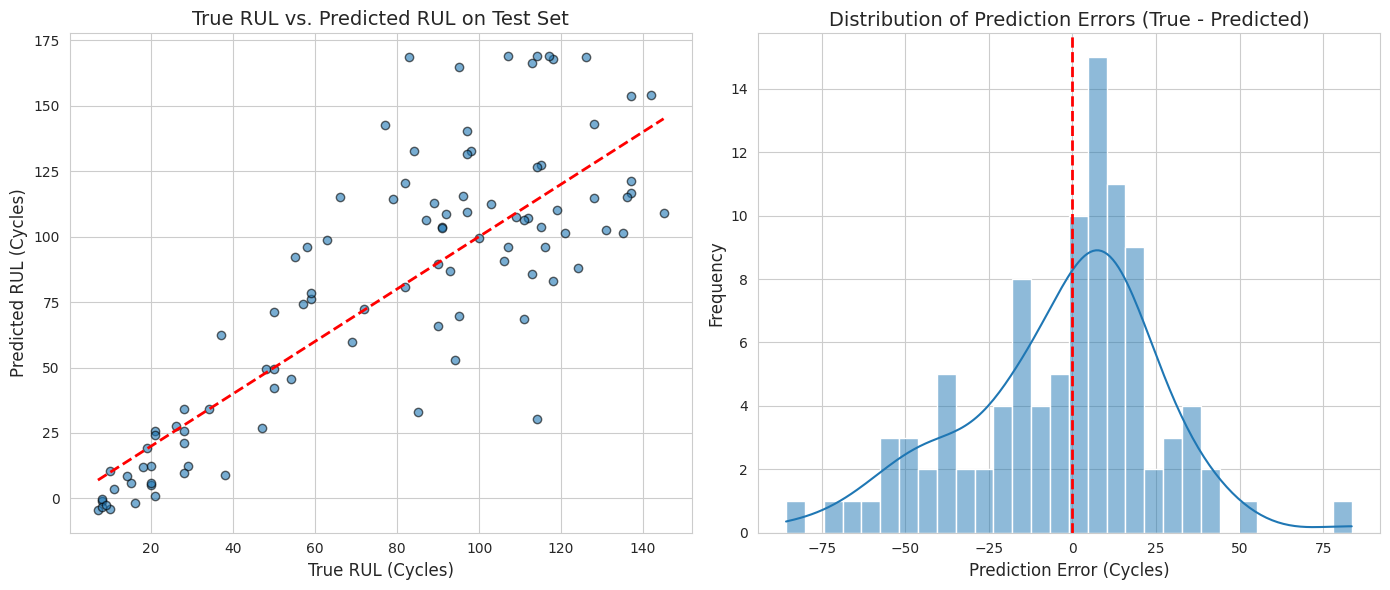

In [87]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test_np_flat, y_pred_test, alpha=0.6, edgecolors='k')
plt.plot([min(y_test_np_flat), max(y_test_np_flat)], [min(y_test_np_flat), max(y_test_np_flat)], color='red', linestyle='--', lw=2)
plt.title('True RUL vs. Predicted RUL on Test Set', fontsize=14)
plt.xlabel('True RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.grid(True)
errors = y_test_np_flat - y_pred_test
plt.subplot(1, 2, 2)
sns.histplot(errors, bins=30, kde=True)
plt.title('Distribution of Prediction Errors (True - Predicted)', fontsize=14)
plt.xlabel('Prediction Error (Cycles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', lw=2)
plt.grid(True)
plt.tight_layout()
plt.show()